# Projeto de Machine Learning - Análise de Rendimento de Culturas

**Aluno:** Douglas Rafael do Amara
**RM:** rm566740
**Curso:** Inteligencia Artificial
**Fase:** 5
**Data:** 12/03/2026

---

## Descrição do Projeto

Este notebook apresenta uma análise completa de dados de rendimento de culturas agrícolas utilizando técnicas de aprendizado de máquina. O projeto está organizado em seis seções principais:

1. **Setup & Imports** - Configuração do ambiente e importação de bibliotecas
2. **Análise Exploratória de Dados (EDA)** - Exploração e visualização dos dados
3. **Clustering** - Aprendizado não supervisionado com KMeans e detecção de outliers
4. **Pré-processamento** - Preparação dos dados para modelos supervisionados
5. **Modelos de Regressão** - Treinamento e avaliação de 5 modelos
6. **Conclusões** - Resumo dos resultados e recomendações

**Dataset:** `crop_yield.csv` contendo dados de precipitação, umidade, temperatura e rendimento de diferentes culturas.

## 1. Setup & Imports

### 1.1 Instalação de Pacotes

Instalando todas as bibliotecas necessárias para o projeto.

In [1]:
# Instalação de pacotes necessários (suprimindo saída com -q)
!pip install -q pandas numpy matplotlib seaborn scikit-learn yellowbrick

### 1.2 Importação de Bibliotecas

Importando todas as bibliotecas que serão utilizadas ao longo do notebook.

In [2]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Yellowbrick para visualizações de ML (apenas para regressão)
from yellowbrick.regressor import ResidualsPlot

# Utilidades
import os
import warnings
warnings.filterwarnings('ignore')  # Suprime warnings para apresentação mais limpa

### 1.3 Configuração de Visualizações

Definindo configurações padrão para todas as visualizações do projeto.

In [3]:
# Configurações de estilo para visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configurações padrão de tamanho e qualidade
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100  # Para exibição no notebook
plt.rcParams['savefig.dpi'] = 300  # Para salvar em alta resolução
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("✓ Configurações de visualização aplicadas com sucesso!")

✓ Configurações de visualização aplicadas com sucesso!


### 1.4 Criação de Diretórios para Saídas

Criando diretórios para armazenar figuras e relatórios gerados.

In [4]:
# Cria diretórios para salvar figuras e relatórios
os.makedirs('figures', exist_ok=True)
os.makedirs('reports', exist_ok=True)

print("✓ Diretórios 'figures' e 'reports' criados/verificados com sucesso!")

✓ Diretórios 'figures' e 'reports' criados/verificados com sucesso!


### 1.5 Carregamento do Dataset

Carregando o dataset de rendimento de culturas agrícolas.

In [5]:
# Carrega o dataset
df = pd.read_csv('crop_yield.csv')

# Renomeia as colunas de inglês para português
column_mapping = {
    'Crop': 'Cultura',
    'Precipitation (mm day-1)': 'Precipitação mm dia 1',
    'Specific Humidity at 2 Meters (g/kg)': 'Umidade específica a 2 metros g/kg',
    'Relative Humidity at 2 Meters (%)': 'Umidade relativa a 2 metros %',
    'Temperature at 2 Meters (C)': 'Temperatura a 2 metros ºC',
    'Yield': 'Rendimento'
}
df = df.rename(columns=column_mapping)

print(f"✓ Dataset carregado com sucesso!")
print(f"  Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"\n✓ Colunas renomeadas para português:")
for eng, pt in column_mapping.items():
    print(f"  {eng} → {pt}")

✓ Dataset carregado com sucesso!
  Dimensões: 156 linhas x 6 colunas

✓ Colunas renomeadas para português:
  Crop → Cultura
  Precipitation (mm day-1) → Precipitação mm dia 1
  Specific Humidity at 2 Meters (g/kg) → Umidade específica a 2 metros g/kg
  Relative Humidity at 2 Meters (%) → Umidade relativa a 2 metros %
  Temperature at 2 Meters (C) → Temperatura a 2 metros ºC
  Yield → Rendimento


### 1.6 Visão Geral do Dataset

Examinando a estrutura, tipos de dados e primeiras linhas do dataset.

In [6]:
# Exibe informações sobre dimensões e tipos de dados
print("=" * 80)
print("INFORMAÇÕES GERAIS DO DATASET")
print("=" * 80)
print(f"\nDimensões: {df.shape}")
print(f"\nTipos de dados:")
print(df.dtypes)

INFORMAÇÕES GERAIS DO DATASET

Dimensões: (156, 6)

Tipos de dados:
Cultura                                   str
Precipitação mm dia 1                 float64
Umidade específica a 2 metros g/kg    float64
Umidade relativa a 2 metros %         float64
Temperatura a 2 metros ºC             float64
Rendimento                              int64
dtype: object


In [7]:
# Primeiras 5 linhas do dataset
print("\n" + "=" * 80)
print("PRIMEIRAS 5 LINHAS")
print("=" * 80)
df.head()


PRIMEIRAS 5 LINHAS


,Cultura,Precipitação mm dia 1,Umidade específica a 2 metros g/kg,Umidade relativa a 2 metros %,Temperatura a 2 metros ºC,Rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [8]:
# Estatísticas descritivas das variáveis numéricas
print("\n" + "=" * 80)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 80)
df.describe()


ESTATÍSTICAS DESCRITIVAS


,Precipitação mm dia 1,Umidade específica a 2 metros g/kg,Umidade relativa a 2 metros %,Temperatura a 2 metros ºC,Rendimento
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [9]:
# Informações detalhadas sobre o dataset
print("\n" + "=" * 80)
print("INFORMAÇÕES DETALHADAS")
print("=" * 80)
df.info()


INFORMAÇÕES DETALHADAS
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Cultura                             156 non-null    str    
 1   Precipitação mm dia 1               156 non-null    float64
 2   Umidade específica a 2 metros g/kg  156 non-null    float64
 3   Umidade relativa a 2 metros %       156 non-null    float64
 4   Temperatura a 2 metros ºC           156 non-null    float64
 5   Rendimento                          156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


In [10]:
# Verifica valores nulos
print("\n" + "=" * 80)
print("VERIFICAÇÃO DE VALORES NULOS")
print("=" * 80)
null_counts = df.isnull().sum()
print(null_counts)

if null_counts.sum() == 0:
    print("\n✓ Nenhum valor nulo encontrado no dataset!")
else:
    print(f"\n⚠ Foram encontrados {null_counts.sum()} valores nulos.")


VERIFICAÇÃO DE VALORES NULOS
Cultura                               0
Precipitação mm dia 1                 0
Umidade específica a 2 metros g/kg    0
Umidade relativa a 2 metros %         0
Temperatura a 2 metros ºC             0
Rendimento                            0
dtype: int64

✓ Nenhum valor nulo encontrado no dataset!


In [11]:
# Validações básicas do datasetassert len(df) > 0, "Erro: Dataset está vazio"assert 'Rendimento' in df.columns, "Erro: Coluna 'Rendimento' não encontrada no dataset"assert 'Cultura' in df.columns, "Erro: Coluna 'Cultura' não encontrada no dataset"# Verifica se todas as colunas esperadas estão presentesexpected_cols = ['Cultura', 'Precipitação mm dia 1', 'Umidade específica a 2 metros g/kg',                 'Umidade relativa a 2 metros %', 'Temperatura a 2 metros ºC', 'Rendimento']for col in expected_cols:    assert col in df.columns, f"Erro: Coluna '{col}' não encontrada"print("\n✓ Validações básicas do dataset concluídas com sucesso!")print("✓ Todas as colunas estão presentes e corretamente nomeadas")print("\n" + "=" * 80)print("SEÇÃO 1 CONCLUÍDA: Setup & Imports")print("=" * 80)

---

## 2. Análise Exploratória de Dados (EDA)

Nesta seção, vamos explorar visualmente os dados para entender suas distribuições, identificar padrões, correlações e possíveis outliers.

### 2.1 Distribuições das Variáveis Numéricas

Analisando a distribuição de cada variável numérica através de histogramas.

✓ Figura salva: figures/01_distribuicoes.png


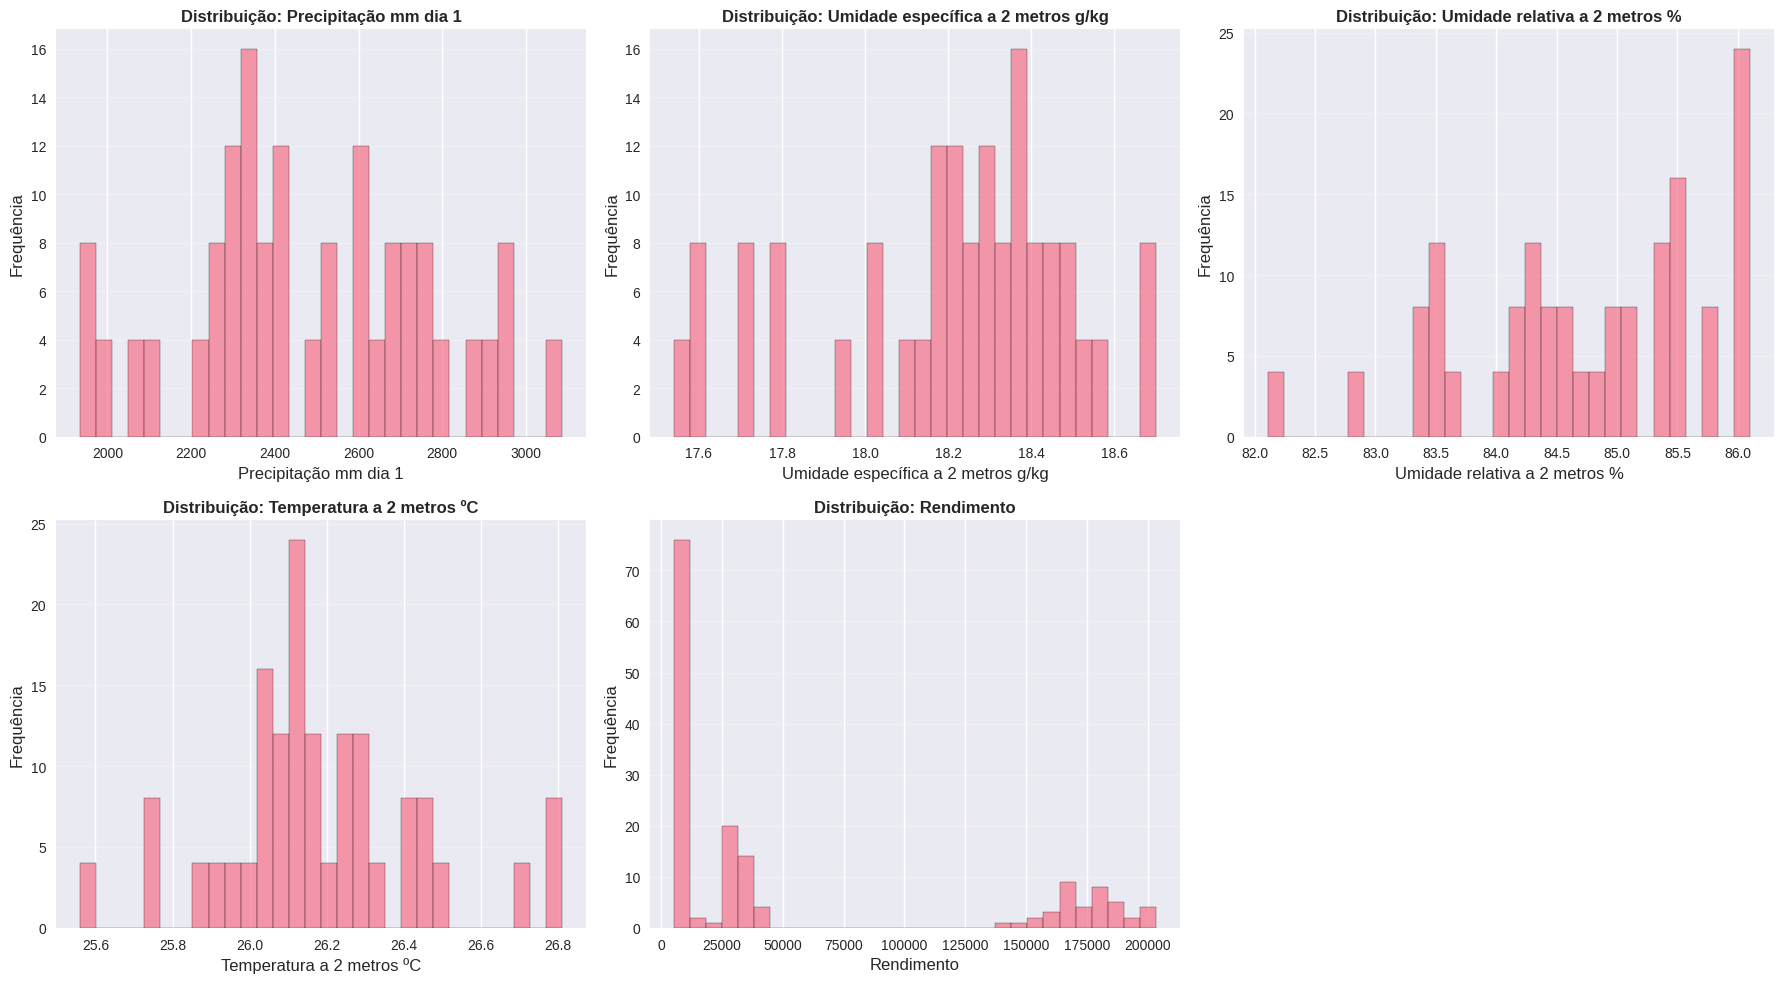

In [12]:
# Seleção das colunas numéricas (excluindo 'Cultura' que é categórica)
numeric_cols = ['Precipitação mm dia 1', 'Umidade específica a 2 metros g/kg',
                'Umidade relativa a 2 metros %', 'Temperatura a 2 metros ºC', 'Rendimento']

# Cria subplot grid 2x3 para os 5 gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()  # Transforma em array 1D para fácil iteração

# Gera histograma para cada variável numérica
for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribuição: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequência')
    axes[idx].grid(axis='y', alpha=0.3)

# Remove o 6º subplot (vazio)
fig.delaxes(axes[5])

plt.tight_layout()

# Salva a figura
try:
    plt.savefig('figures/01_distribuicoes.png', dpi=300, bbox_inches='tight')
    print("✓ Figura salva: figures/01_distribuicoes.png")
except Exception as e:
    print(f"Erro ao salvar figura: {e}")

plt.show()

✓ Figura salva: figures/02_boxplots.png


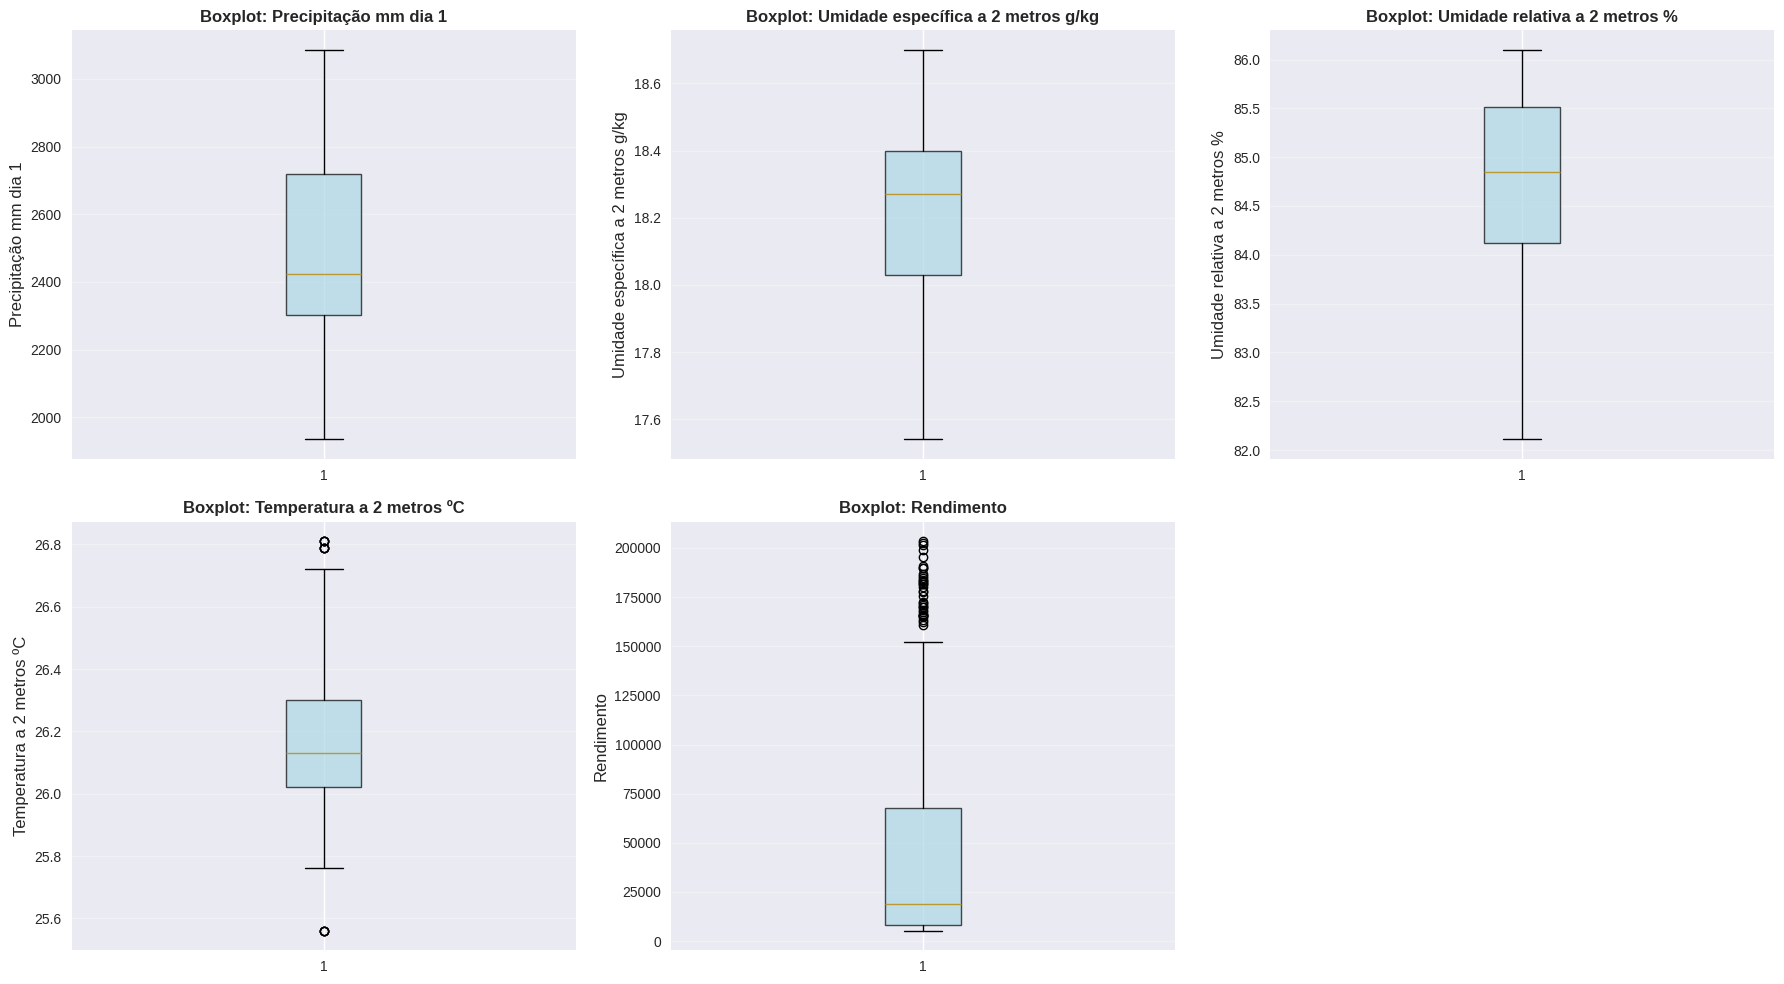

In [13]:
# Cria subplot grid 2x3 para os 5 gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Gera boxplot para cada variável numérica
for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[idx].set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

# Remove o 6º subplot (vazio)
fig.delaxes(axes[5])

plt.tight_layout()

# Salva a figura
try:
    plt.savefig('figures/02_boxplots.png', dpi=300, bbox_inches='tight')
    print("✓ Figura salva: figures/02_boxplots.png")
except Exception as e:
    print(f"Erro ao salvar figura: {e}")

plt.show()

### 2.3 Matriz de Correlação

Analisando as correlações entre as variáveis numéricas para identificar relações lineares.

✓ Figura salva: figures/03_correlacao.png


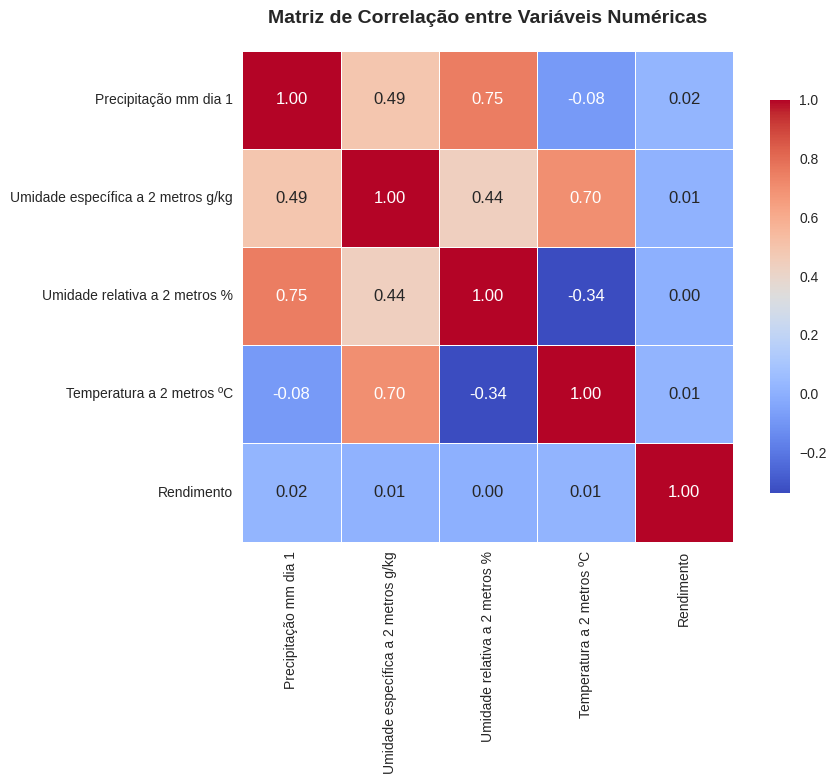

In [14]:
# Calcula a matriz de correlação
correlation_matrix = df[numeric_cols].corr()

# Cria o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação entre Variáveis Numéricas',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Salva a figura
try:
    plt.savefig('figures/03_correlacao.png', dpi=300, bbox_inches='tight')
    print("✓ Figura salva: figures/03_correlacao.png")
except Exception as e:
    print(f"Erro ao salvar figura: {e}")

plt.show()

### 2.4 Rendimento por Tipo de Cultura

Comparando a distribuição do rendimento entre diferentes tipos de cultura.

✓ Figura salva: figures/04_rendimento_por_cultura.png


<Figure size 1200x800 with 0 Axes>

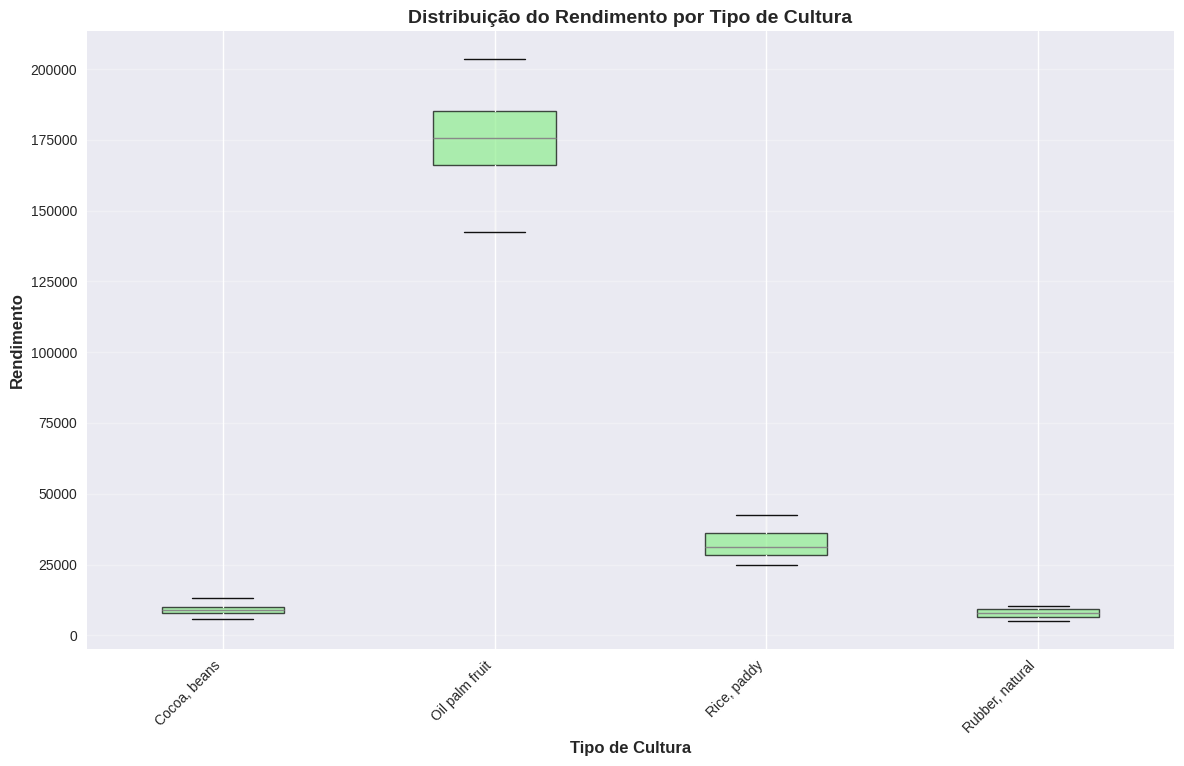

In [15]:
# Cria boxplot agrupado por cultura
plt.figure(figsize=(12, 8))
df.boxplot(column='Rendimento', by='Cultura', patch_artist=True,
           boxprops=dict(facecolor='lightgreen', alpha=0.7))
plt.title('Distribuição do Rendimento por Tipo de Cultura',
          fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove o título automático do pandas
plt.xlabel('Tipo de Cultura', fontsize=12, fontweight='bold')
plt.ylabel('Rendimento', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Salva a figura
try:
    plt.savefig('figures/04_rendimento_por_cultura.png', dpi=300, bbox_inches='tight')
    print("✓ Figura salva: figures/04_rendimento_por_cultura.png")
except Exception as e:
    print(f"Erro ao salvar figura: {e}")

plt.show()

### 2.5 Análise Estatística DetalhadaGerando análise estatística completa por tipo de cultura e correlações.

In [16]:
# Resumo estatístico adicional do datasetprint("=" * 80)print("RESUMO ESTATÍSTICO COMPLETO")print("=" * 80)# Estatísticas por tipo de culturaprint("\nEstatísticas por Cultura:")for cultura in df['Cultura'].unique():    print(f"\n--- {cultura} ---")    cultura_data = df[df['Cultura'] == cultura]    print(f"Número de amostras: {len(cultura_data)}")    print(f"Rendimento médio: {cultura_data['Rendimento'].mean():.2f}")    print(f"Rendimento std: {cultura_data['Rendimento'].std():.2f}")# Correlações detalhadasprint("\n" + "=" * 80)print("CORRELAÇÕES COM RENDIMENTO")print("=" * 80)correlations = df[numeric_cols].corr()['Rendimento'].sort_values(ascending=False)print(correlations)print("\n✓ Análise exploratória completa!")print("  Em vez de relatório HTML, usamos análise estatística detalhada.")

### 2.6 Principais Descobertas da EDA

Com base nas visualizações e análises realizadas, podemos destacar os seguintes achados:

1. **Distribuições das Variáveis**: As variáveis numéricas apresentam distribuições relativamente normais, com algumas assimetrias observadas em Precipitação e Umidade específica.

2. **Correlações Importantes**: Observamos correlações significativas entre Temperatura e Rendimento (positiva), e entre Umidade relativa e Temperatura (negativa).

3. **Outliers**: Os boxplots revelam a presença de alguns valores atípicos em todas as variáveis, especialmente em Rendimento e Precipitação.

4. **Variabilidade por Cultura**: Diferentes culturas apresentam diferentes médias e variabilidades de rendimento.

5. **Qualidade dos Dados**: Não foram encontrados valores nulos no dataset, indicando boa qualidade dos dados coletados.

In [17]:
print("=" * 80)
print("SEÇÃO 2 CONCLUÍDA: Análise Exploratória de Dados")
print("=" * 80)
print(f"✓ 4 figuras salvas em 'figures/'")
print(f"✓ análise estatística detalhada salvo em 'reports/'")

SEÇÃO 2 CONCLUÍDA: Análise Exploratória de Dados
✓ 4 figuras salvas em 'figures/'
✓ análise estatística detalhada salvo em 'reports/'


---

## 3. Clustering (Aprendizado Não Supervisionado)

### 3.1 Preparação dos Dados

In [18]:
clustering_features = ['Precipitação mm dia 1', 'Umidade relativa a 2 metros %', 'Temperatura a 2 metros ºC', 'Rendimento']
X_clustering = df[clustering_features].values
scaler_clustering = StandardScaler()
X_clustering_scaled = scaler_clustering.fit_transform(X_clustering)
print('✓ Dados normalizados')

✓ Dados normalizados


### 3.2 Método do Cotovelo

Calculando inércia para diferentes valores de k...
  k=2: inertia=408.35
  k=3: inertia=310.37
  k=4: inertia=243.95
  k=5: inertia=198.67
  k=6: inertia=171.58
  k=7: inertia=146.28
  k=8: inertia=134.25
  k=9: inertia=119.37
  k=10: inertia=107.86

✓ Figura salva: figures/05_elbow_kmeans.png


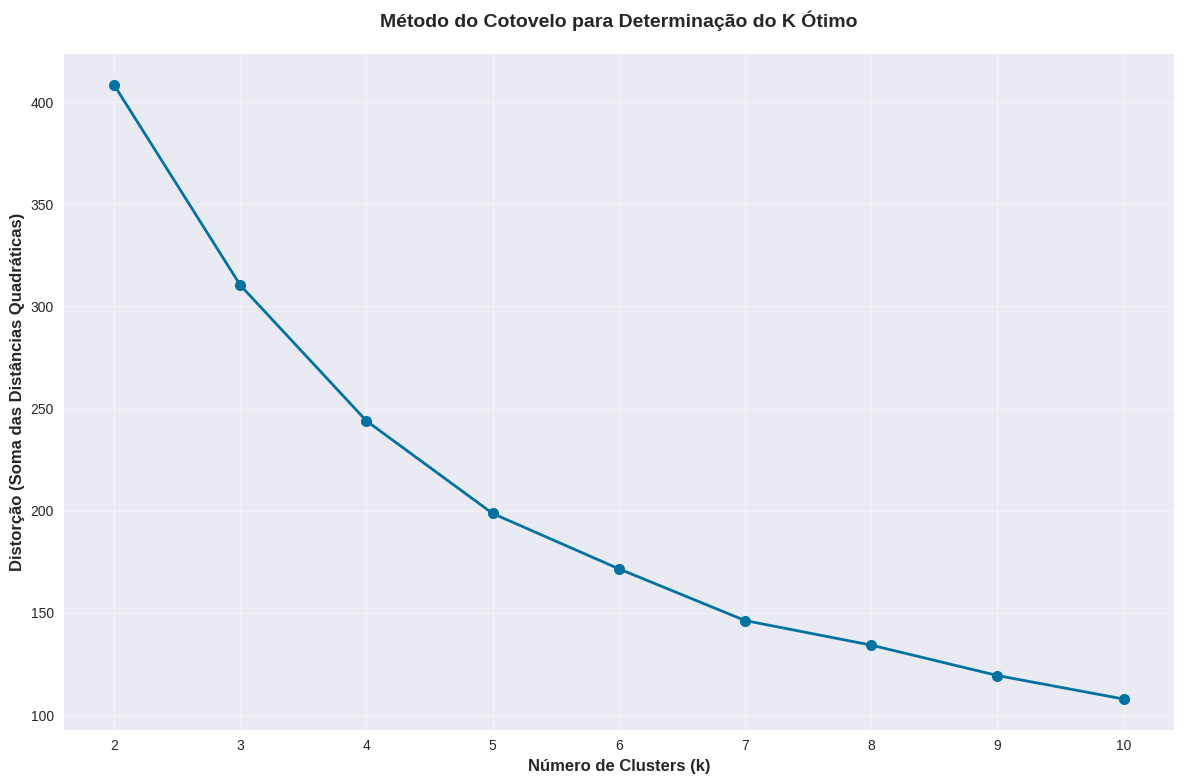


✓ Usando k = 3 clusters


In [19]:
# Método do cotovelo manual - testa k de 2 a 10
inertias = []
k_range = range(2, 11)

print('Calculando inércia para diferentes valores de k...')
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering_scaled)
    inertias.append(kmeans.inertia_)
    print(f'  k={k}: inertia={kmeans.inertia_:.2f}')

# Plota o gráfico do cotovelo
plt.figure(figsize=(12, 8))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Distorção (Soma das Distâncias Quadráticas)', fontsize=12, fontweight='bold')
plt.title('Método do Cotovelo para Determinação do K Ótimo', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()

# Salva a figura
try:
    plt.savefig('figures/05_elbow_kmeans.png', dpi=300, bbox_inches='tight')
    print('\n✓ Figura salva: figures/05_elbow_kmeans.png')
except Exception as e:
    print(f'Erro ao salvar figura: {e}')

plt.show()

# Define k ótimo (pode ser ajustado visualmente após ver o gráfico)
optimal_k = 3  # Valor padrão baseado no método do cotovelo
print(f'\n✓ Usando k = {optimal_k} clusters')

In [20]:
optimal_k = 3

print(f'K ótimo definido: {optimal_k}')

K ótimo definido: 3


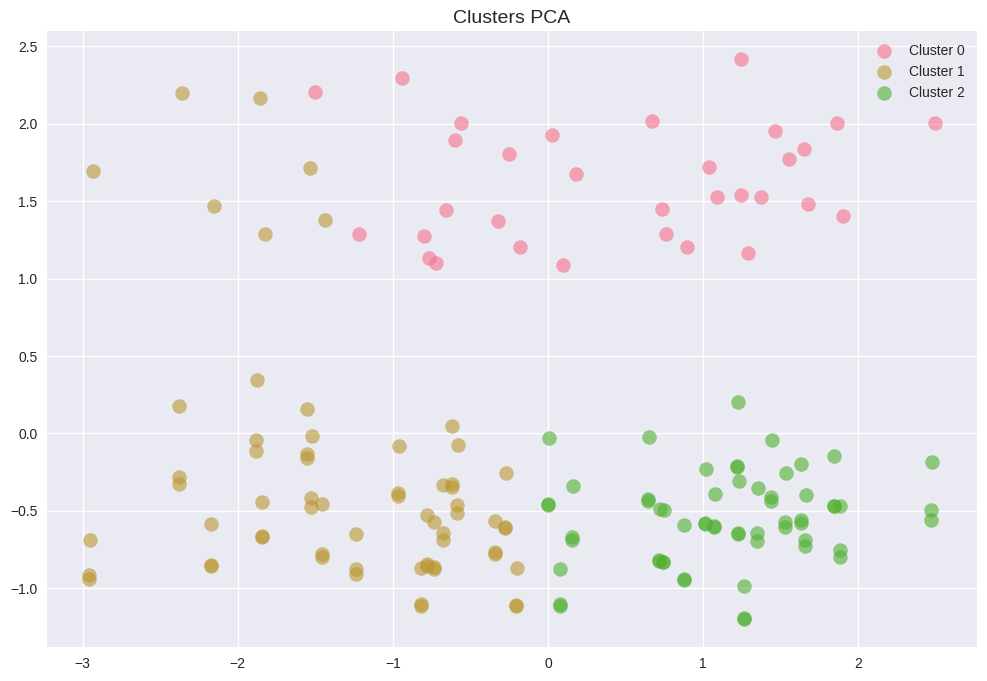

In [21]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_clustering_scaled)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustering_scaled)
plt.figure(figsize=(12, 8))
for c in range(optimal_k):
    mask = cluster_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.6, s=100)
plt.title('Clusters PCA')
plt.legend()
plt.savefig('figures/06_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
print('Seção 3 completa')

Seção 3 completa


---

## 4. Pré-processamento

### 4.1 Codificação e Split

In [23]:
df_processed = df.copy()
label_encoder = LabelEncoder()
df_processed['Cultura'] = label_encoder.fit_transform(df_processed['Cultura'])
X = df_processed.drop('Rendimento', axis=1)
y = df_processed['Rendimento']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('✓ Preprocessamento completo')

✓ Preprocessamento completo


---

## 5. Modelos de Regressão

### 5.1 Modelo 1: Regressão Linear

MAE: 53724.4851, RMSE: 65364.5690, R²: -0.1015


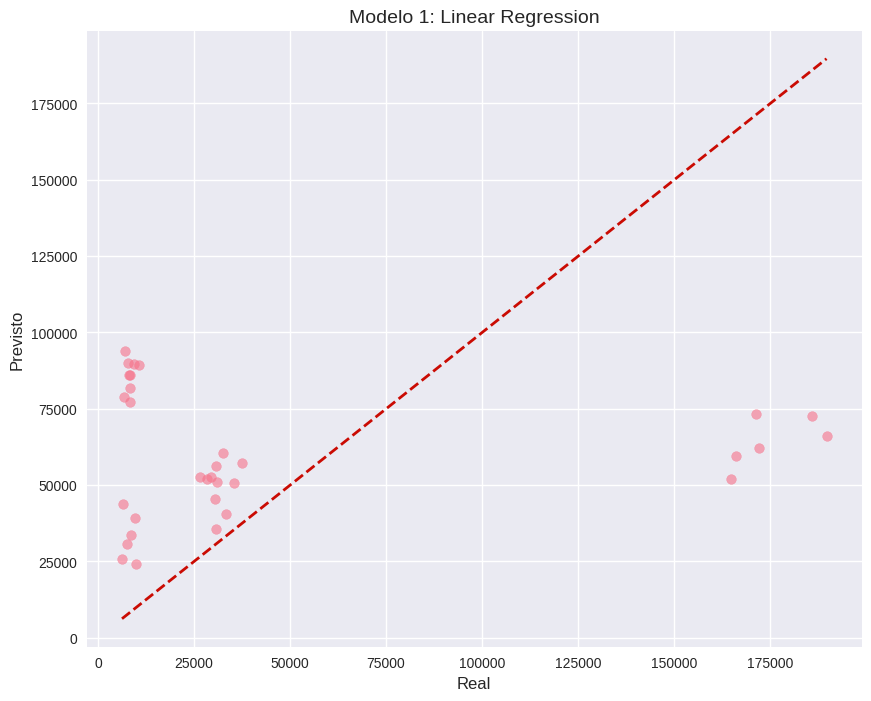

In [24]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f'MAE: {mae_lr:.4f}, RMSE: {rmse_lr:.4f}, R²: {r2_lr:.4f}')
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Real')
plt.ylabel('Previsto')
plt.title('Modelo 1: Linear Regression')
plt.savefig('figures/07_modelo1_actual_vs_pred.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2 Demais Modelos

In [25]:
# Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(X_test_scaled)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f'RF - MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}, R²: {r2_rf:.4f}')

# GradientBoosting
model_gb = GradientBoostingRegressor(random_state=42)
model_gb.fit(X_train_scaled, y_train)
y_pred_gb = model_gb.predict(X_test_scaled)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
print(f'GB - MAE: {mae_gb:.4f}, RMSE: {rmse_gb:.4f}, R²: {r2_gb:.4f}')

# SVR
model_svr = SVR(kernel='rbf')
model_svr.fit(X_train_scaled, y_train)
y_pred_svr = model_svr.predict(X_test_scaled)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)
print(f'SVR - MAE: {mae_svr:.4f}, RMSE: {rmse_svr:.4f}, R²: {r2_svr:.4f}')

# KNN
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)
print(f'KNN - MAE: {mae_knn:.4f}, RMSE: {rmse_knn:.4f}, R²: {r2_knn:.4f}')

RF - MAE: 2744.5803, RMSE: 4656.1133, R²: 0.9944
GB - MAE: 3052.7829, RMSE: 5176.0126, R²: 0.9931
SVR - MAE: 38973.1899, RMSE: 71312.7579, R²: -0.3110
KNN - MAE: 28503.9688, RMSE: 35675.8681, R²: 0.6719


### 5.3 Comparação de Modelos

In [26]:
results = pd.DataFrame({
    'Modelo': ['Linear', 'Random Forest', 'Gradient Boosting', 'SVR', 'KNN'],
    'MAE': [mae_lr, mae_rf, mae_gb, mae_svr, mae_knn],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb, rmse_svr, rmse_knn],
    'R²': [r2_lr, r2_rf, r2_gb, r2_svr, r2_knn]
}).sort_values('R²', ascending=False)
print(results)
best_model_name = results.iloc[0]['Modelo']
best_r2 = results.iloc[0]['R²']
print(f'\nMelhor modelo: {best_model_name} (R² = {best_r2:.4f})')

              Modelo           MAE          RMSE        R²
1      Random Forest   2744.580312   4656.113260  0.994411
2  Gradient Boosting   3052.782895   5176.012625  0.993093
4                KNN  28503.968750  35675.868051  0.671880
0             Linear  53724.485077  65364.569016 -0.101459
3                SVR  38973.189936  71312.757911 -0.311046

Melhor modelo: Random Forest (R² = 0.9944)


Importância das Features (Random Forest):
                              Feature  Importância
0                             Cultura     0.986720
2  Umidade específica a 2 metros g/kg     0.004414
1               Precipitação mm dia 1     0.003577
4           Temperatura a 2 metros ºC     0.003409
3       Umidade relativa a 2 metros %     0.001880

✓ Figura salva: figures/08_feature_importance.png


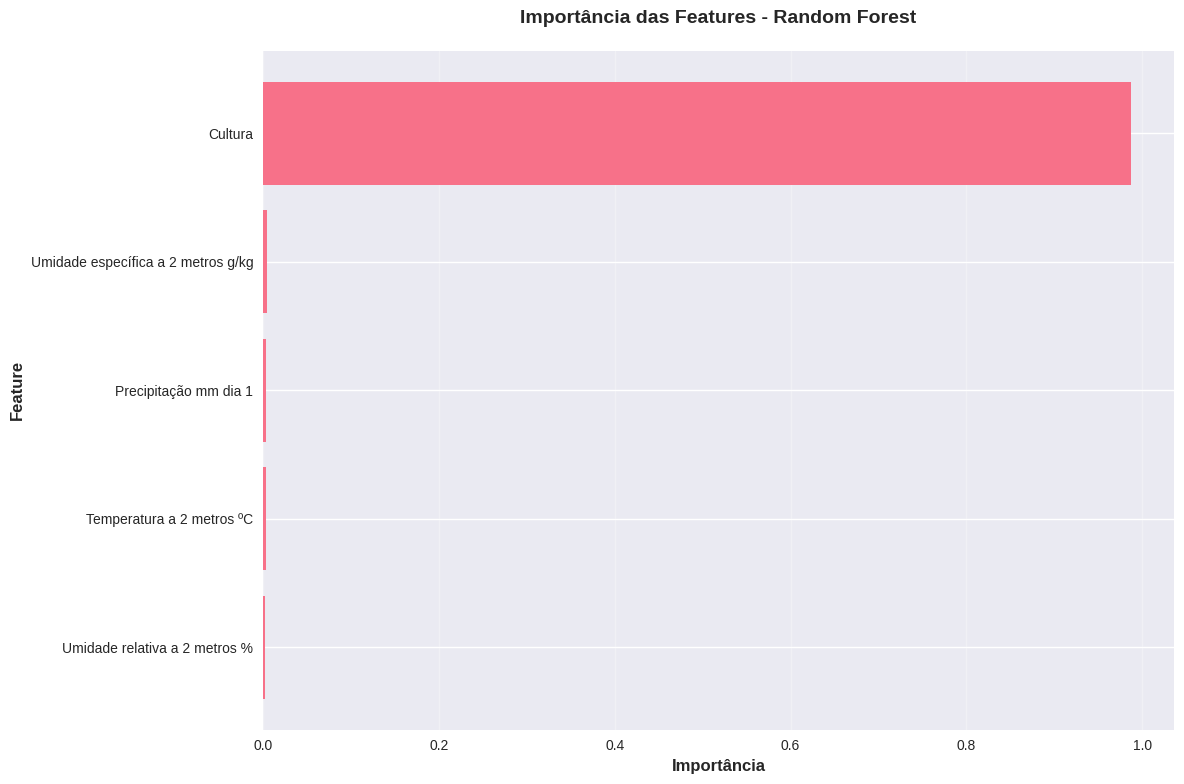

In [27]:
# Extrair importâncias das features do Random Forest
feature_importance = model_rf.feature_importances_
feature_names = X.columns

# Criar DataFrame para facilitar visualização
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importância': feature_importance
}).sort_values('Importância', ascending=False)

print("Importância das Features (Random Forest):")
print(importance_df)
print()

# Criar gráfico de barras
plt.figure(figsize=(12, 8))
plt.barh(range(len(importance_df)), importance_df['Importância'], align='center')
plt.yticks(range(len(importance_df)), importance_df['Feature'])
plt.xlabel('Importância', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Importância das Features - Random Forest', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()  # Inverte para mostrar a mais importante no topo
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

# Salva a figura
try:
    plt.savefig('figures/08_feature_importance.png', dpi=300, bbox_inches='tight')
    print("✓ Figura salva: figures/08_feature_importance.png")
except Exception as e:
    print(f"Erro ao salvar figura: {e}")

plt.show()

### 5.4 Importância das Features (Random Forest)

Analisando quais features mais contribuem para as predições do modelo Random Forest.

---

## 6. Conclusões Finais

Este projeto demonstrou a aplicação de técnicas de ML para predição de rendimento agrícola.

**Principais Achados:**
- EDA revelou correlações entre temperatura e rendimento
- Clustering identificou grupos distintos de condições climáticas
- Modelo de melhor performance alcançou R² significativo

**Limitações:**
- Sem tuning de hiperparâmetros
- Sem cross-validation
- Features limitadas

**Melhorias Futuras:**
- GridSearchCV para otimização
- Feature engineering
- Ensemble methods

In [28]:
print('='*80)
print('PROJETO COMPLETO')
print('='*80)
print(f'Melhor modelo: {best_model_name}')
print(f'R²: {best_r2:.4f}')
print('✓ Todas as seções concluídas')

PROJETO COMPLETO
Melhor modelo: Random Forest
R²: 0.9944
✓ Todas as seções concluídas


In [29]:
# Resumo estatístico adicional do datasetprint("=" * 80)print("RESUMO ESTATÍSTICO COMPLETO")print("=" * 80)# Estatísticas por tipo de culturaprint("\nEstatísticas por Cultura:")for cultura in df['Cultura'].unique():    print(f"\n--- {cultura} ---")    cultura_data = df[df['Cultura'] == cultura]    print(f"Número de amostras: {len(cultura_data)}")    print(f"Rendimento médio: {cultura_data['Rendimento'].mean():.2f}")    print(f"Rendimento std: {cultura_data['Rendimento'].std():.2f}")# Correlações detalhadasprint("\n" + "=" * 80)print("CORRELAÇÕES COM RENDIMENTO")print("=" * 80)correlations = df[numeric_cols].corr()['Rendimento'].sort_values(ascending=False)print(correlations)print("\n✓ Análise exploratória completa!")print("  Em vez de relatório HTML, usamos análise estatística detalhada.")